In [9]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_curve, 
    roc_auc_score,
    accuracy_score,
    confusion_matrix,
    f1_score
)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('/Users/ekaterinaselihovkina/Documents/GitHub/ML2_project/WineQuality.csv')

In [2]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.400000,0.700000,0.000000,1.900000,0.076000,11.000000,34.000000,0.997800,3.510000,0.560000,9.400000,5.000000
1,7.800000,0.880000,0.000000,2.600000,0.098000,25.000000,67.000000,0.996800,3.200000,0.680000,9.800000,5.000000
2,7.800000,0.760000,0.040000,2.300000,0.092000,15.000000,54.000000,0.997000,3.260000,0.650000,9.800000,5.000000
3,11.200000,0.280000,0.560000,1.900000,0.075000,17.000000,60.000000,0.998000,3.160000,0.580000,9.800000,6.000000
4,7.400000,0.700000,0.000000,1.900000,0.076000,11.000000,34.000000,0.997800,3.510000,0.560000,9.400000,5.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
1694,7.801551,0.774154,0.241745,2.715859,0.079321,16.037881,10.405468,0.994029,3.557283,0.514583,9.366488,3.897010
1695,7.207143,0.290908,0.590842,3.962575,0.055079,39.435754,78.763287,0.996134,2.925239,1.046480,8.942161,4.307249
1696,10.100031,0.964682,0.540634,3.333877,0.115459,24.801783,71.432995,0.997277,3.327200,0.647539,9.619507,5.409358
1697,5.372036,0.510212,0.078397,0.982824,0.095933,30.435484,76.676115,0.993783,3.158328,0.817616,9.375978,5.454616


In [5]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1699.000000,1699.000000,1699.000000,1699.000000,1699.000000,1699.000000,1699.000000,1699.000000,1699.000000,1699.000000,1699.000000,1699.000000
mean,8.329397,0.526786,0.271403,2.549096,0.087544,16.048253,46.897874,0.996747,3.311263,0.657206,10.421607,5.638028
std,1.726301,0.178695,0.194009,1.399910,0.046900,10.490591,32.733365,0.001887,0.154309,0.169189,1.066080,0.809308
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.094784,1.900000,0.070000,8.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.091000,22.000000,63.000000,0.997860,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1699 entries, 0 to 1698
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1699 non-null   float64
 1   volatile acidity      1699 non-null   float64
 2   citric acid           1699 non-null   float64
 3   residual sugar        1699 non-null   float64
 4   chlorides             1699 non-null   float64
 5   free sulfur dioxide   1699 non-null   float64
 6   total sulfur dioxide  1699 non-null   float64
 7   density               1699 non-null   float64
 8   pH                    1699 non-null   float64
 9   sulphates             1699 non-null   float64
 10  alcohol               1699 non-null   float64
 11  quality               1699 non-null   float64
dtypes: float64(12)
memory usage: 159.4 KB


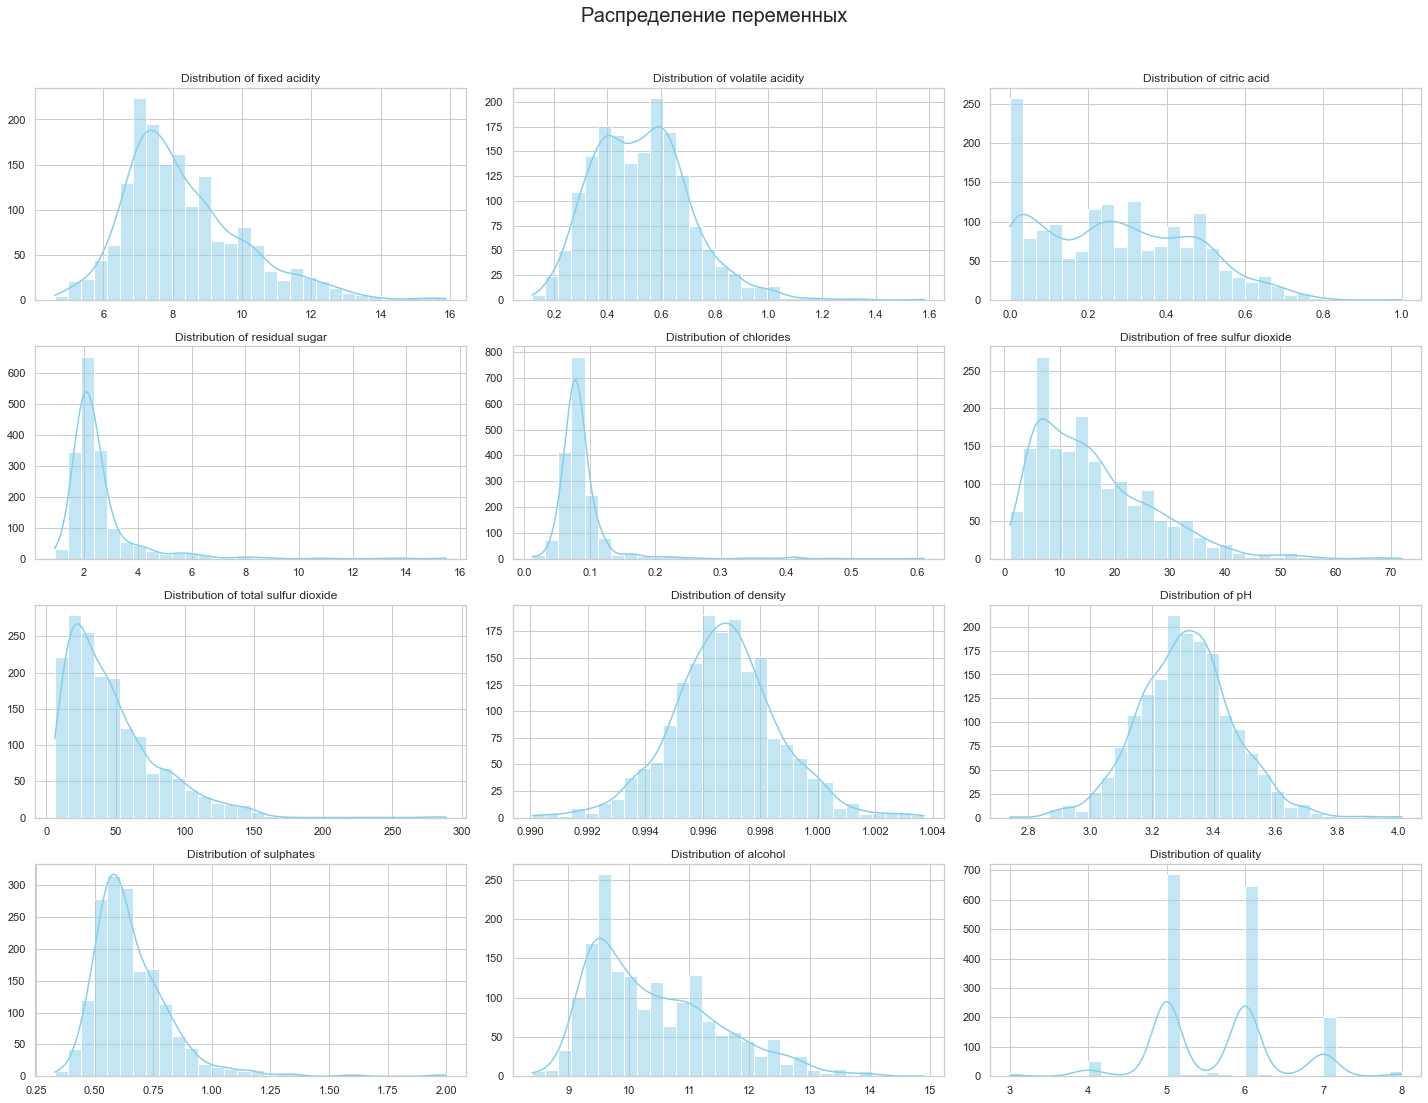

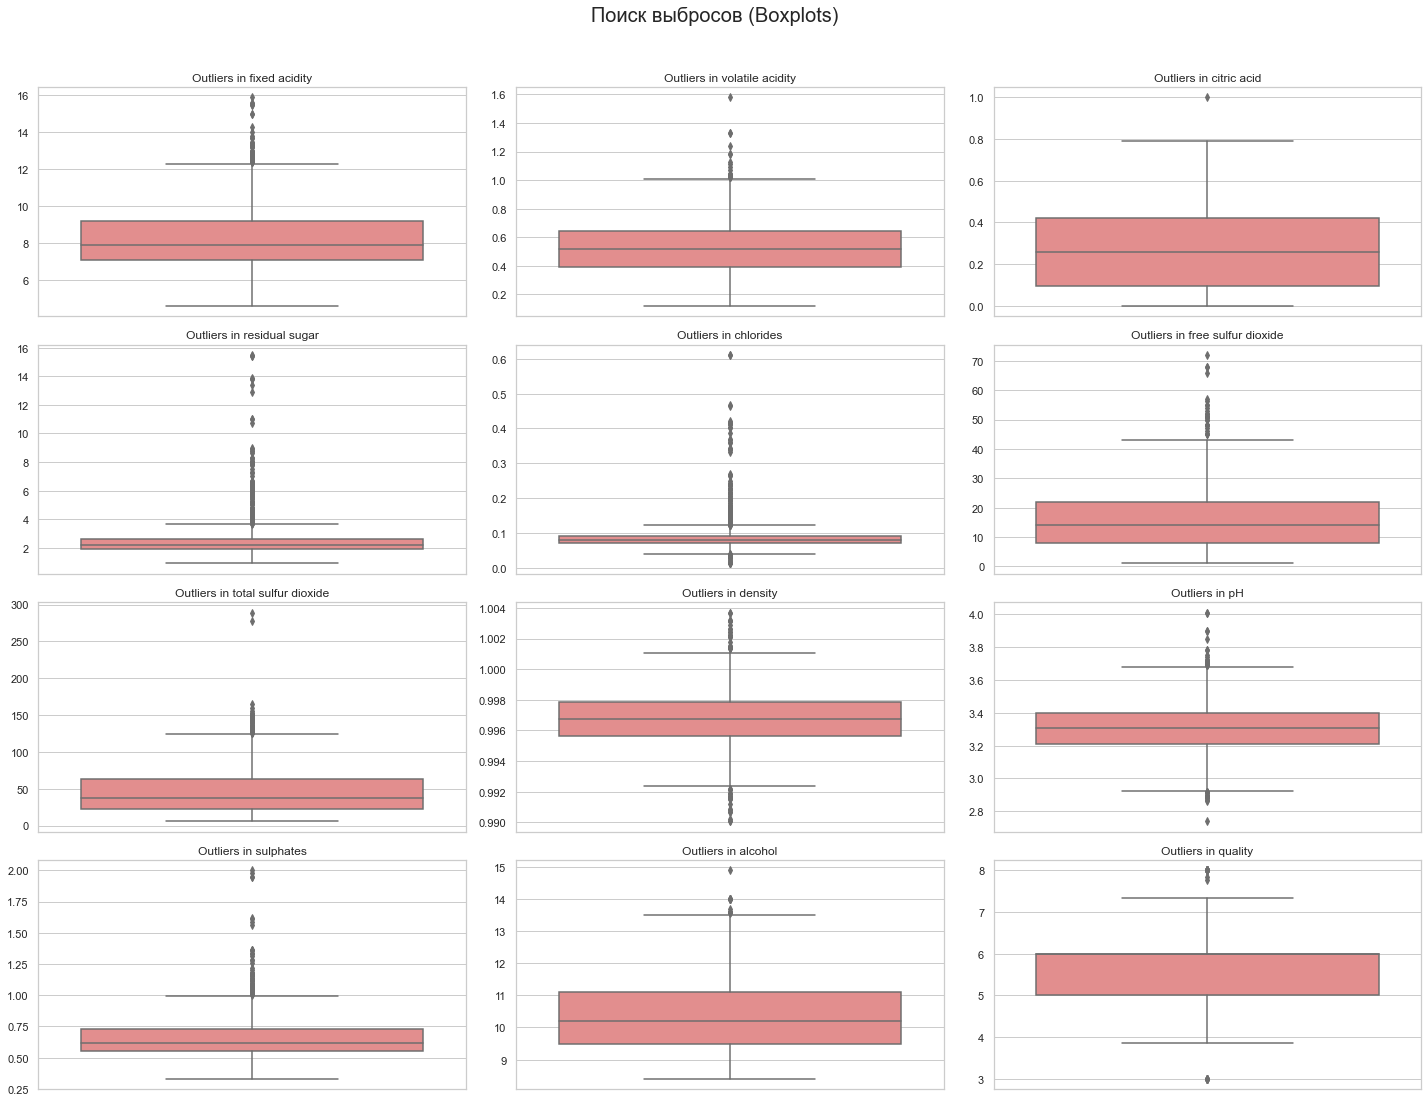

In [6]:
cols = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
    'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
    'pH', 'sulphates', 'alcohol', 'quality']

sns.set_theme(style="whitegrid")
plt.figure(figsize=(20, 15))
plt.suptitle('Распределение переменных', fontsize=20, y=1.02)

for i, col in enumerate(cols):
    plt.subplot(4, 3, i + 1)
    sns.histplot(df[col], kde=True, color='skyblue', bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel('')
    plt.ylabel('')

plt.tight_layout()
plt.show()

#outliers
plt.figure(figsize=(20, 15))
plt.suptitle('Поиск выбросов (Boxplots)', fontsize=20, y=1.02)

for i, col in enumerate(cols):
    plt.subplot(4, 3, i + 1)
    sns.boxplot(y=df[col], color='lightcoral')
    plt.title(f'Outliers in {col}')
    plt.ylabel('')

plt.tight_layout()
plt.show()

/var/folders/2g/_w78wl3s5m52qkfws_d5sxyh0000gn/T/ipykernel_31108/2545704311.py:6: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar()


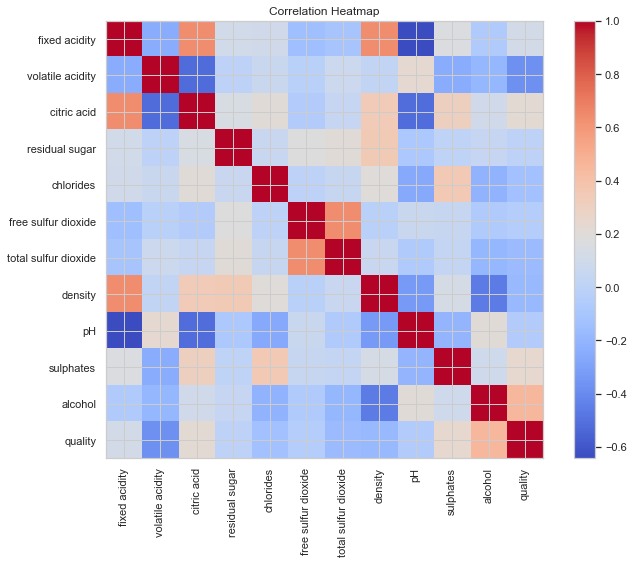

In [8]:
corr = df["alcohol"].corr(df["quality"], method="pearson")
corr_matrix = df.select_dtypes(include='number').corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, cmap="coolwarm", interpolation="nearest")
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [11]:
from sklearn.model_selection import train_test_split


X = df.iloc[:, :-1] 
y = df.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

Размер обучающей выборки: (1359, 11)
Размер тестовой выборки: (340, 11)


In [13]:
X_train

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
438,10.400000,0.410000,0.550000,3.200000,0.076000,22.000000,54.000000,0.999600,3.150000,0.890000,9.900000
548,12.400000,0.350000,0.490000,2.600000,0.079000,27.000000,69.000000,0.999400,3.120000,0.750000,10.400000
1187,7.000000,0.430000,0.300000,2.000000,0.085000,6.000000,39.000000,0.993460,3.330000,0.460000,11.900000
1445,7.400000,0.785000,0.190000,5.200000,0.094000,19.000000,98.000000,0.997130,3.160000,0.520000,9.600000
1657,8.887466,0.303796,0.450977,2.278107,0.062864,26.847723,23.298178,0.994088,3.070791,0.760872,9.058471
...,...,...,...,...,...,...,...,...,...,...,...
1130,9.100000,0.600000,0.000000,1.900000,0.058000,5.000000,10.000000,0.997700,3.180000,0.630000,10.400000
1294,8.200000,0.635000,0.100000,2.100000,0.073000,25.000000,60.000000,0.996380,3.290000,0.750000,10.900000
860,7.200000,0.620000,0.060000,2.700000,0.077000,15.000000,85.000000,0.997460,3.510000,0.540000,9.500000
1459,7.900000,0.200000,0.350000,1.700000,0.054000,7.000000,15.000000,0.994580,3.320000,0.800000,11.900000


In [16]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score


rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)


mse = mean_squared_error(y_test, y_pred_rf)
r2 = r2_score(y_test, y_pred_rf)

print(f"MSE: {mse}")
print(f"R2 Score: {r2}")

MSE: 0.35380339066869165
R2 Score: 0.4157808429051335
